
<div style="margin:0; padding:0;">



####  **1. Description of notebook**</p>
#####  In this notebook, we will train a model that can use speech data from Parkinson's patients and healthy control to predict whether one subject has Parkinson's disease or not.The input of this model are</p>
#####  1. Mel Spectrogram, which has a size of 60 x T, where T is determined by the length of the recording.</p>
#####  2. Static features extracted from original recording (*eg*. jimmer, shimmer, NHR *etc*) that is not time-related。</p>

</div>

#### **2. Data preprocessing
##### The original data has data from non-Parkinson's patient who performs acoustic task other than prolonged-vowel. We need to extract data from Parkinson's patients and we should only contain data from prolonged-vowel, otherwise our training data is not comparable to independent validation data. Reference this step to sort_by_diagnosis.py, sort_by_task.py, sort_static.py



#### **3. Data cleaning for Mel Spectrogram
##### Data may present in Parkinson's data and heathy control at the same time. To remove duplicate data, run following

##### Label participant status and check which participant is duplicated

In [17]:
import pandas as pd

control_tsv = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/control.tsv" #path to control data
patient_tsv = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/parkinsons_disease.tsv" #path to parkinson data

ctrl_ids = set(pd.read_csv(control_tsv, sep="\t", dtype=str)["participant_id"].str.strip())
pat_ids  = set(pd.read_csv(patient_tsv, sep="\t", dtype=str)["participant_id"].str.strip())

overlap = ctrl_ids & pat_ids
print("overlap:", len(overlap))  #  0 means no duplicate

overlap: 0


##### Remove duplicate

In [4]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc

in_path = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/torchaudio_mel_spectrogram.parquet" #choose which file to process
out_path = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/filtered/torchaudio_mel_spectrogram_filtered.parquet"

BAD_ID = "007388"   # <- Replace with duplicate participant_id
PID_COL = "participant_id"

pf = pq.ParquetFile(in_path)
writer = None
removed = 0
kept = 0

for batch in pf.iter_batches(batch_size=2048):  
    tbl = pa.Table.from_batches([batch])

    if PID_COL not in tbl.column_names:
        raise ValueError(f"{in_path} no Column {PID_COL}，Actual Column：{tbl.column_names}")

    pid = pc.cast(tbl[PID_COL], pa.string())
    mask_keep = pc.not_equal(pid, pa.scalar(BAD_ID))

    out_tbl = tbl.filter(mask_keep)
    removed += (tbl.num_rows - out_tbl.num_rows)
    kept += out_tbl.num_rows

    if out_tbl.num_rows > 0:
        if writer is None:
            writer = pq.ParquetWriter(out_path, out_tbl.schema, compression="zstd")
        writer.write_table(out_tbl)

if writer is not None:
    writer.close()

print(f"done. kept={kept}, removed={removed}, saved={out_path}")

done. kept=142, removed=0, saved=/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/filtered/torchaudio_mel_spectrogram_filtered.parquet


#### 4. Mel Spectrogram Visualization

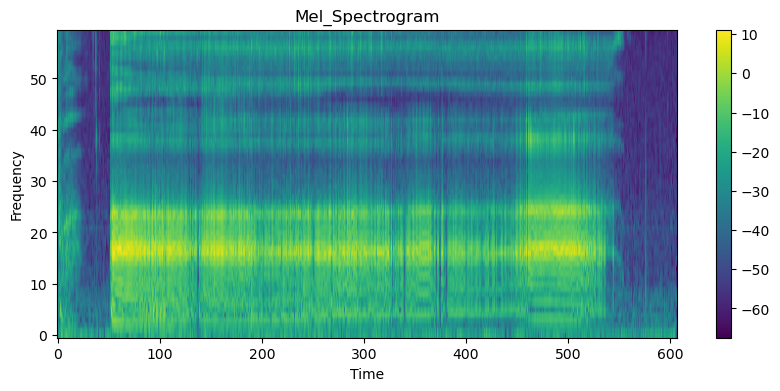

In [13]:
from datasets import Dataset
import numpy as np
import matplotlib.pyplot as plt
ds = Dataset.from_parquet("/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/filtered/torchaudio_mel_spectrogram_filtered.parquet")
import librosa
spectrogram = librosa.power_to_db(np.asarray(ds[22]['mel_spectrogram']))
plt.figure(figsize=(10, 4))
plt.imshow(spectrogram, aspect='auto', origin='lower')
plt.title('Mel_Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar()

#### 5. Check Mel Spectrogram T (recording length) consistency.

In [14]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pandas as pd

parquet_path = "/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet" #merged parkinson and control data
pf = pq.ParquetFile(parquet_path)

# read n_frames + task_name
rows = []
for b in pf.iter_batches(batch_size=4096, columns=["task_name", "n_frames"]):
    t = b.to_pydict()
    for task, nf in zip(t["task_name"], t["n_frames"]):
        if task == "prolonged-vowel":
            rows.append(nf)

s = pd.Series(rows)
print("N=", len(s))
print("p50=", s.quantile(0.5), "p95=", s.quantile(0.95), "min=", s.min(), "max=", s.max())

N= 290
p50= 607.0 p95= 607.0 min= 209 max= 641


#### 6. Load and check data for Conv2D training

In [15]:
import pyarrow.parquet as pq
import numpy as np
import torch
from torch.utils.data import Dataset

class MelInMemoryDataset(Dataset):
    def __init__(self, parquet_path, ctrl_ids, pat_ids, T0=512, train=True, log1p=True):
        self.T0 = T0
        self.train = train
        self.log1p = log1p

        ctrl_ids = set(ctrl_ids)
        pat_ids = set(pat_ids)

        table = pq.read_table(parquet_path, columns=["participant_id","task_name","mel_spectrogram"])
        d = table.to_pydict()

        X, Y, P = [], [], []
        for pid, task, mel in zip(d["participant_id"], d["task_name"], d["mel_spectrogram"]):
            pid = str(pid).strip()
            if task != "prolonged-vowel":
                continue
            if pid in ctrl_ids:
                y = 0
            elif pid in pat_ids:
                y = 1
            else:
                continue

            x = np.asarray(mel, dtype=np.float32)  # (60, T)
            if self.log1p:
                x = np.log1p(np.maximum(x, 0.0))
            x = pad_or_crop(x, T0=self.T0, train=self.train)
            x = per_bin_standardize(x)
            X.append(x)
            Y.append(y)
            P.append(pid)

        self.X = torch.from_numpy(np.stack(X)).unsqueeze(1)  # [N,1,60,T0]
        self.Y = torch.tensor(Y, dtype=torch.long)
        self.P = P
        print(f"[INFO] in-memory dataset: N={len(self.Y)}  pos={int(self.Y.sum())}  neg={len(self.Y)-int(self.Y.sum())}")

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.P[idx]

In [16]:
import numpy as np

def pad_or_crop(x, T0, train=True):
    """
    x: np.ndarray, shape (60, T)
    return: shape (60, T0)
    """
    C, T = x.shape
    if T == T0:
        return x
    if T > T0:
        # train random crop；eval central crop
        if train:
            start = np.random.randint(0, T - T0 + 1)
        else:
            start = (T - T0) // 2
        return x[:, start:start + T0]
    else:
        out = np.zeros((C, T0), dtype=x.dtype)
        out[:, :T] = x
        return out

def per_bin_standardize(x, eps=1e-6):
    """
    x: np.ndarray, shape (60, T0)
    normalize each mel bin in time-dimension
    """
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True)
    return (x - m) / (s + eps)

from torch.utils.data import DataLoader

ds = MelInMemoryDataset(
    parquet_path="/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet",
    ctrl_ids=ctrl_ids,
    pat_ids=pat_ids,
    T0=512,
    train=True
)

loader = DataLoader(ds, batch_size=16, shuffle=True)
xb, yb, pidb = next(iter(loader))
print(xb.shape, yb.shape, pidb[:3])
# expected results：torch.Size([16, 1, 60, 512])

[INFO] in-memory dataset: N=290  pos=142  neg=148
torch.Size([16, 1, 60, 512]) torch.Size([16]) ('656551', '502326', '718998')


#### 7. Train CNN model with Recall Preference and 5-fold CV

In [19]:
import os, random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.metrics import accuracy_score, f1_score

# ------------------
# Directory Setting
# ------------------
PARQUET_PATH = "/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet"
CONTROL_TSV  = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/control.tsv"
PATIENT_TSV  = "/home/taor/work/bridge2AI-data/Gituploading/dataset/phenotype/diagnosis/parkinsons_disease.tsv"
TASK = "prolonged-vowel"

T0 = 607              # based on p50/p95
BATCH_SIZE = 16
EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8          # early stopping
N_SPLITS = 5
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_ids(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t", dtype=str)
    if "participant_id" in df.columns:
        s = df["participant_id"]
    else:
        s = df.iloc[:, 0]
    return set(s.astype(str).str.strip().dropna().tolist())


def per_bin_standardize(x, eps=1e-6):
    # x: (60, T)
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True)
    return (x - m) / (s + eps)


def pad_or_crop(x, T0, train=True):
    # x: (60, T)
    C, T = x.shape
    if T == T0:
        return x
    if T > T0:
        if train:
            start = np.random.randint(0, T - T0 + 1)
        else:
            start = (T - T0) // 2
        return x[:, start:start + T0]
    else:
        out = np.zeros((C, T0), dtype=x.dtype)
        out[:, :T] = x
        return out


def load_mel_samples(parquet_path, ctrl_ids, pat_ids, task=TASK):
    table = pq.read_table(parquet_path, columns=["participant_id","task_name","mel_spectrogram","n_frames"])
    d = table.to_pydict()

    X_raw = []
    y = []
    pids = []
    lengths = []
    skipped = []

    for pid, tname, mel, nf in zip(d["participant_id"], d["task_name"], d["mel_spectrogram"], d["n_frames"]):
        pid = str(pid).strip()
        if tname != task:
            continue

        if pid in ctrl_ids:
            label = 0
        elif pid in pat_ids:
            label = 1
        else:
            continue

        # Skip missing and outlier
        if mel is None:
            skipped.append((pid, "mel None"))
            continue
        x = np.asarray(mel, dtype=np.float32)
        if x.ndim != 2 or x.shape[0] != 60 or x.shape[1] == 0:
            skipped.append((pid, f"bad shape {x.shape}"))
            continue
        # skip nf/T inconsistency
        if int(nf) != x.shape[1]:
            skipped.append((pid, f"n_frames mismatch {nf} vs {x.shape[1]}"))
            continue

        X_raw.append(x)      
        y.append(label)
        pids.append(pid)
        lengths.append(x.shape[1])

    if len(X_raw) == 0:
        raise ValueError("No sample：check task_name、ID 、parquet column name。")

    print(f"[INFO] loaded N={len(X_raw)}  pos={sum(y)}  neg={len(y)-sum(y)}  skipped={len(skipped)}")
    if skipped:
        print("[INFO] skipped examples:", skipped[:10])
    return X_raw, np.array(y, dtype=int), pids, np.array(lengths, dtype=int)


class MelDataset(Dataset):
    def __init__(self, X_raw, y, indices, T0=607, train=True, use_log1p=False):
        self.X_raw = X_raw
        self.y = y
        self.idx = np.array(indices, dtype=int)
        self.T0 = T0
        self.train = train
        self.use_log1p = use_log1p

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        x = self.X_raw[j]  # (60, T)

        
        if self.use_log1p:
            x = np.log1p(np.maximum(x, 0.0))

        
        x = per_bin_standardize(x)

        
        x = pad_or_crop(x, self.T0, train=self.train)

        # to tensor: [1, 60, T0]
        x = torch.from_numpy(x).unsqueeze(0).float()
        y = torch.tensor(self.y[j]).long()
        return x, y


class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # -> [16, 30, ~T/2]

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),   # -> [32, 15, ~T/4]

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    probs = []
    ys = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(p)
        ys.append(yb.numpy())
    probs = np.concatenate(probs)
    ys = np.concatenate(ys)
    return ys, probs
from sklearn.metrics import precision_score, recall_score

def pick_threshold_for_min_recall(y_true, p_pred, min_recall=0.85):
    """
    check thrs：make recall >= min_recall，and as high as possible
    return: best_thr, (best_precision, best_recall)
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)

  
    thresholds = np.unique(np.quantile(p_pred, np.linspace(0.0, 1.0, 201)))
    best = None  # (precision, recall, thr)

    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        if rec < min_recall:
            continue
        pre = precision_score(y_true, y_hat, zero_division=0)
        cand = (pre, rec, float(thr))
        if best is None or cand[0] > best[0] + 1e-12: 
            best = cand

    # maximize recell if recall thrs does not meet
    if best is None:
        best_rec = -1
        best_pre = -1
        best_thr = 0.0
        for thr in thresholds:
            y_hat = (p_pred >= thr).astype(int)
            rec = recall_score(y_true, y_hat, zero_division=0)
            pre = precision_score(y_true, y_hat, zero_division=0)
            if rec > best_rec + 1e-12:
                best_rec, best_pre, best_thr = rec, pre, float(thr)
        return best_thr, (best_pre, best_rec)

    return best[2], (best[0], best[1])

def main():
    set_seed(SEED)

    ctrl_ids = read_ids(CONTROL_TSV)
    pat_ids  = read_ids(PATIENT_TSV)

    overlap = ctrl_ids & pat_ids
    if len(overlap) != 0:
        raise ValueError(f"find control/patient ID overlap: {len(overlap)}，remove duplicate，：{list(overlap)[:10]}")

    X_raw, y, pids, lengths = load_mel_samples(PARQUET_PATH, ctrl_ids, pat_ids, TASK)
    print(f"[INFO] n_frames: p50={np.quantile(lengths,0.5)}  p95={np.quantile(lengths,0.95)}  min={lengths.min()}  max={lengths.max()}")
    print(f"[INFO] Using T0={T0}")

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    fold_rows = []
    all_aurocs, all_pre, all_rec, all_acc, all_f1 = [], [], [], [], []

    for fold, (tr, va) in enumerate(skf.split(np.zeros_like(y), y), 1):
        print(f"\n===== Fold {fold}/{N_SPLITS} =====")

        ds_tr = MelDataset(X_raw, y, tr, T0=T0, train=True,  use_log1p=False)
        ds_va = MelDataset(X_raw, y, va, T0=T0, train=False, use_log1p=False)

        dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
        dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        model = SmallCNN().to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        best_auc = -1.0
        best_state = None
        patience = 0

        for epoch in range(1, EPOCHS + 1):
            loss = train_one_epoch(model, dl_tr, optimizer, DEVICE)
            y_va, p_va = eval_model(model, dl_va, DEVICE)

            auc = roc_auc_score(y_va, p_va)
            print(f"epoch {epoch:03d}  loss={loss:.4f}  val_AUROC={auc:.4f}")

            if auc > best_auc + 1e-4:
                best_auc = auc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience = 0
            else:
                patience += 1
                if patience >= PATIENCE:
                    print(f"[EARLY STOP] best_AUROC={best_auc:.4f}")
                    break

       
        model.load_state_dict(best_state)
        
        y_tr, p_tr = eval_model(model, dl_tr, DEVICE)     
        thr, (pre_tr, rec_tr) = pick_threshold_for_min_recall(y_tr, p_tr, min_recall=0.85)
        print(f"[FOLD {fold}] picked thr={thr:.4f} on train  (Precision={pre_tr:.3f}, Recall={rec_tr:.3f})")

        
        y_va, p_va = eval_model(model, dl_va, DEVICE)
        auc = roc_auc_score(y_va, p_va)
        y_hat = (p_va >= thr).astype(int)
        pre = precision_score(y_va, y_hat, zero_division=0)
        rec = recall_score(y_va, y_hat, zero_division=0)
        acc = accuracy_score(y_va, y_hat)
        f1  = f1_score(y_va, y_hat, zero_division=0)
        print(f"[FOLD {fold}] AUROC={auc:.4f}  Precision={pre:.4f}  Recall={rec:.4f}")

        fold_rows.append({"fold": fold, "AUROC": auc, "Precision": pre, "Recall": rec,"Accuracy": acc,"F1": f1})
        all_aurocs.append(auc); all_pre.append(pre); all_rec.append(rec);all_acc.append(acc);all_f1.append(f1)

    df = pd.DataFrame(fold_rows)
    df.to_csv("cnn_mel_5fold_results.csv", index=False)

    print("\n===== Summary =====")
    print(df)
    print(f"AUROC    mean±std = {np.mean(all_aurocs):.4f} ± {np.std(all_aurocs):.4f}")
    print(f"Precision mean±std = {np.mean(all_pre):.4f} ± {np.std(all_pre):.4f}")
    print(f"Recall    mean±std = {np.mean(all_rec):.4f} ± {np.std(all_rec):.4f}")
    print(f"Accurarcy  mean±std = {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}")
    print(f"F1 SCORE  mean±std = {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}")
    print("[DONE] saved -> cnn_mel_5fold_results.csv")


if __name__ == "__main__":
    main()

[INFO] loaded N=290  pos=142  neg=148  skipped=0
[INFO] n_frames: p50=607.0  p95=607.0  min=209  max=641
[INFO] Using T0=607

===== Fold 1/5 =====
epoch 001  loss=0.6979  val_AUROC=0.7488
epoch 002  loss=0.6851  val_AUROC=0.7512
epoch 003  loss=0.6761  val_AUROC=0.7762
epoch 004  loss=0.6714  val_AUROC=0.7881
epoch 005  loss=0.6641  val_AUROC=0.7667
epoch 006  loss=0.6637  val_AUROC=0.7845
epoch 007  loss=0.6526  val_AUROC=0.7929
epoch 008  loss=0.6514  val_AUROC=0.7917
epoch 009  loss=0.6430  val_AUROC=0.7738
epoch 010  loss=0.6360  val_AUROC=0.7845
epoch 011  loss=0.6369  val_AUROC=0.7762
epoch 012  loss=0.6274  val_AUROC=0.7488
epoch 013  loss=0.6192  val_AUROC=0.7631
epoch 014  loss=0.6164  val_AUROC=0.7643
epoch 015  loss=0.6177  val_AUROC=0.7702
[EARLY STOP] best_AUROC=0.7929
[FOLD 1] picked thr=0.4202 on train  (Precision=0.590, Recall=0.860)
[FOLD 1] AUROC=0.7929  Precision=0.6316  Recall=0.8571

===== Fold 2/5 =====
epoch 001  loss=0.7191  val_AUROC=0.6060
epoch 002  loss=0.69

#### 8. Data visualization for static features
##### Refer to findStaticOutliers.py
#### 9. Try different model to learn relationship between static features.
##### Refer to tryTrainForStaticFeature.py. Results suggest that Catboost has the best performance among all models

#### 10. Merge Catboost and CNN with platt scaling and weight grid search

In [20]:
import os, random
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier


# =========================
# 1) Directory Setting
# =========================
MEL_PARQUET = "/home/taor/work/bridge2AI-data/Gituploading/dataset/merged_data/Patien_Control_merge_spectrogram.parquet"  # mel parquet
TASK = "prolonged-vowel"
CONTROL_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/control_data/vowel_task_data/static_control_prolonged-vowel.tsv"
PATIENT_STATIC_TSV = "/home/taor/work/bridge2AI-data/Gituploading/dataset/parkingson_data/vowel_task_data/static_parkinson_prolonged-vowel.tsv"

#  p50=p95=607 -> 607
T0 = 607

# CNN parameters
BATCH_SIZE = 16
EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8

# CV parameters
N_SPLITS = 5
SEED = 42

# recall thres
MIN_RECALL = 0.85

# Merge
W_GRID = np.linspace(0, 1, 21)  # weighted average 的 w 搜索：0~1 步长0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# 2) Toolkit parameters
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_ids(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t", dtype=str)
    if "participant_id" in df.columns:
        s = df["participant_id"]
    else:
        s = df.iloc[:, 0]
    return set(s.astype(str).str.strip().dropna().tolist())


def per_bin_standardize(x, eps=1e-6):
    # x: (60, T)
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True)
    return (x - m) / (s + eps)


def pad_or_crop(x, T0, train=True):
    # x: (60, T)
    C, T = x.shape
    if T == T0:
        return x
    if T > T0:
        if train:
            start = np.random.randint(0, T - T0 + 1)
        else:
            start = (T - T0) // 2
        return x[:, start:start + T0]
    else:
        out = np.zeros((C, T0), dtype=x.dtype)
        out[:, :T] = x
        return out


def pick_threshold_for_min_recall(y_true, p_pred, min_recall=0.85):
    """
    Recall preference setting
    """
    y_true = np.asarray(y_true).astype(int)
    p_pred = np.asarray(p_pred).astype(float)

    thresholds = np.unique(np.quantile(p_pred, np.linspace(0.0, 1.0, 201)))
    best = None  # (precision, recall, thr)

    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        if rec < min_recall:
            continue
        pre = precision_score(y_true, y_hat, zero_division=0)
        cand = (pre, rec, float(thr))
        if best is None or cand[0] > best[0] + 1e-12:
            best = cand

    if best is not None:
        return best[2]

    # 达不到 min_recall：选 recall 最大的阈值
    best_rec, best_pre, best_thr = -1, -1, 0.0
    for thr in thresholds:
        y_hat = (p_pred >= thr).astype(int)
        rec = recall_score(y_true, y_hat, zero_division=0)
        pre = precision_score(y_true, y_hat, zero_division=0)
        if rec > best_rec + 1e-12:
            best_rec, best_pre, best_thr = rec, pre, float(thr)
    return best_thr


def fit_platt_calibrator(y, p):
    """
    Platt scaling with logistic regression
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float).reshape(-1, 1)
    lr = LogisticRegression(solver="liblinear", max_iter=200)
    lr.fit(p, y)
    return lr


def apply_calibrator(calibrator, p):
    p = np.asarray(p).astype(float).reshape(-1, 1)
    return calibrator.predict_proba(p)[:, 1]


# =========================
# 3) read data
# =========================
def load_mel_samples(parquet_path, ctrl_ids, pat_ids, task=TASK):
    table = pq.read_table(parquet_path, columns=["participant_id","task_name","mel_spectrogram","n_frames"])
    d = table.to_pydict()

    X_raw, y, pids, lengths = [], [], [], []
    skipped = []

    for pid, tname, mel, nf in zip(d["participant_id"], d["task_name"], d["mel_spectrogram"], d["n_frames"]):
        pid = str(pid).strip()
        if tname != task:
            continue

        if pid in ctrl_ids:
            label = 0
        elif pid in pat_ids:
            label = 1
        else:
            continue

        if mel is None:
            skipped.append((pid, "mel None"))
            continue

        x = np.asarray(mel, dtype=np.float32)
        if x.ndim != 2 or x.shape[0] != 60 or x.shape[1] == 0:
            skipped.append((pid, f"bad shape {x.shape}"))
            continue
        if int(nf) != x.shape[1]:
            skipped.append((pid, f"n_frames mismatch {nf} vs {x.shape[1]}"))
            continue

        X_raw.append(x)
        y.append(label)
        pids.append(pid)
        lengths.append(x.shape[1])

    if len(X_raw) == 0:
        raise ValueError("No sample read：check parquet column name、task_name、control/patient ID。")

    print(f"[INFO] mel samples: N={len(X_raw)} pos={sum(y)} neg={len(y)-sum(y)} skipped={len(skipped)}")
    if skipped:
        print("[INFO] skipped examples:", skipped[:10])
    lengths = np.array(lengths, dtype=int)
    print(f"[INFO] n_frames: p50={np.quantile(lengths,0.5)} p95={np.quantile(lengths,0.95)} min={lengths.min()} max={lengths.max()}")
    return X_raw, np.array(y, dtype=int), pids


# =========================
# 4) align with static features
# =========================
def load_static_aligned(control_tsv, patient_tsv, pids, task=TASK):
    c = pd.read_csv(control_tsv, sep="\t", dtype=str)
    p = pd.read_csv(patient_tsv, sep="\t", dtype=str)
    c["label"] = 0
    p["label"] = 1

    common = sorted(set(c.columns) & set(p.columns))
    df = pd.concat([c[common], p[common]], ignore_index=True)

    if "task_name" in df.columns:
        df["task_name"] = df["task_name"].astype(str).str.strip()
        df = df[df["task_name"] == task].copy()

    if "participant_id" not in df.columns:
        raise ValueError("static TSV with no participant_id 列")

    df["participant_id"] = df["participant_id"].astype(str).str.strip()
    df = df.drop_duplicates(subset=["participant_id"]).set_index("participant_id")

    # align pid order
    missing = [pid for pid in pids if pid not in df.index]
    if len(missing) > 0:
        print(f"[WARN] static lack {len(missing)} pid（merge failure）：example {missing[:10]}")

    df_aligned = df.loc[[pid for pid in pids if pid in df.index]].copy()
    aligned_pids = df_aligned.index.tolist()

    # exclude missing data
    drop_cols = {"label", "session_id", "task_name"}
    feat_cols = [c for c in df_aligned.columns if c not in drop_cols]

    X = df_aligned[feat_cols].apply(pd.to_numeric, errors="coerce")
    y = df_aligned["label"].astype(int).values

    return X, y, aligned_pids


# =========================
# 5) PyTorch Dataset + CNN
# =========================
class MelDataset(Dataset):
    def __init__(self, X_raw, y, indices, T0=T0, train=True, use_log1p=False):
        self.X_raw = X_raw
        self.y = y
        self.idx = np.array(indices, dtype=int)
        self.T0 = T0
        self.train = train
        self.use_log1p = use_log1p

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        x = self.X_raw[j]  # (60, T)

        if self.use_log1p:
            x = np.log1p(np.maximum(x, 0.0))

        x = per_bin_standardize(x)
        x = pad_or_crop(x, self.T0, train=self.train)

        x = torch.from_numpy(x).unsqueeze(0).float()  # [1,60,T0]
        y = torch.tensor(self.y[j]).long()
        return x, y


class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


def train_one_epoch(model, loader, optimizer):
    model.train()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs, ys = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(p)
        ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(probs)


def fit_cnn_on_fold(X_raw, y, tr_idx, va_idx):
    # train loader（随机裁剪）
    ds_tr = MelDataset(X_raw, y, tr_idx, T0=T0, train=True)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    # eval loader（中心裁剪）用于 early stopping
    ds_va = MelDataset(X_raw, y, va_idx, T0=T0, train=False)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model = SmallCNN().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_auc = -1.0
    best_state = None
    patience = 0

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, dl_tr, opt)
        y_va, p_va = predict_proba(model, dl_va)
        auc = roc_auc_score(y_va, p_va)

        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model


# =========================
# 6) CatBoost training
# =========================
def fit_catboost_on_fold(X, y, tr_idx):
    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        random_seed=SEED,
        verbose=False
    )
    model.fit(X.iloc[tr_idx], y[tr_idx])
    return model


# =========================
# 7) Core metrics
# =========================
def compute_metrics(y_true, p_pred, thr):
    y_hat = (p_pred >= thr).astype(int)
    return {
        "AUROC": roc_auc_score(y_true, p_pred),
        "Precision": precision_score(y_true, y_hat, zero_division=0),
        "Recall": recall_score(y_true, y_hat, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_hat),
        "F1": f1_score(y_true, y_hat, zero_division=0),
    }


# =========================
# 8) Training and merge
# =========================
def main():
    set_seed(SEED)
    print(f"[INFO] device={DEVICE}")

    ctrl_ids = read_ids(CONTROL_STATIC_TSV)
    pat_ids = read_ids(PATIENT_STATIC_TSV)

    overlap = ctrl_ids & pat_ids
    if len(overlap) > 0:
        raise ValueError(f"find control/patient ID overlap={len(overlap)}，exmaple：{list(overlap)[:10]}")

   
    X_raw, y_mel, pids_mel = load_mel_samples(MEL_PARQUET, ctrl_ids, pat_ids, TASK)

 
    X_static, y_static, pids_static = load_static_aligned(CONTROL_STATIC_TSV, PATIENT_STATIC_TSV, pids_mel, TASK)

  
    pid_to_mel_idx = {pid: i for i, pid in enumerate(pids_mel)}
    keep_mel_idx = [pid_to_mel_idx[pid] for pid in pids_static]
    X_raw = [X_raw[i] for i in keep_mel_idx]
    y = np.array([y_mel[i] for i in keep_mel_idx], dtype=int)
    pids = pids_static

  
    if not np.array_equal(y, y_static):
        raise ValueError("mel 与 static 对齐后标签不一致，请检查 ID 划分/过滤逻辑。")

    print(f"[INFO] final aligned N={len(y)} pos={y.sum()} neg={len(y)-y.sum()}")

  
    pd.DataFrame({"participant_id": pids, "y": y}).to_csv("sample_index.tsv", sep="\t", index=False)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    # 
    p_cnn_oof = np.zeros(len(y), dtype=float)
    p_cb_oof = np.zeros(len(y), dtype=float)

    # 
    fold_rows_weighted = []
    fold_rows_stacking = []
    cnn_stats_all = []
    cb_stats_all = []

    for fold, (tr, va) in enumerate(skf.split(np.zeros_like(y), y), 1):
        
        print(f"\n===== Fold {fold}/{N_SPLITS} =====")

        # ---- CNN ----
        cnn = fit_cnn_on_fold(X_raw, y, tr, va)

        dl_tr_eval = DataLoader(MelDataset(X_raw, y, tr, T0=T0, train=False), batch_size=BATCH_SIZE, shuffle=False)
        dl_va_eval = DataLoader(MelDataset(X_raw, y, va, T0=T0, train=False), batch_size=BATCH_SIZE, shuffle=False)

        y_tr, p_tr_cnn = predict_proba(cnn, dl_tr_eval)
        y_va, p_va_cnn = predict_proba(cnn, dl_va_eval)

        # ---- CatBoost ----
        cb = fit_catboost_on_fold(X_static, y, tr)
        p_tr_cb = cb.predict_proba(X_static.iloc[tr])[:, 1]
        p_va_cb = cb.predict_proba(X_static.iloc[va])[:, 1]

        # ---- Calibration----
        # 20% in training set for calibration
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + fold)
        tr_pos = np.arange(len(tr))
        fit_pos, cal_pos = next(sss.split(tr_pos, y[tr]))

   
        y_cal = y[tr][cal_pos]

        p_cal_cnn = p_tr_cnn[cal_pos]
        cal_cnn = fit_platt_calibrator(y_cal, p_cal_cnn)
        p_tr_cnn_cal = apply_calibrator(cal_cnn, p_tr_cnn)
        p_va_cnn_cal = apply_calibrator(cal_cnn, p_va_cnn)

        p_cal_cb = p_tr_cb[cal_pos]
        cal_cb = fit_platt_calibrator(y_cal, p_cal_cb)
        p_tr_cb_cal = apply_calibrator(cal_cb, p_tr_cb)
        p_va_cb_cal = apply_calibrator(cal_cb, p_va_cb)

        # save OOF
        p_cnn_oof[va] = p_va_cnn_cal
        p_cb_oof[va] = p_va_cb_cal

        # CNN
        thr_cnn = pick_threshold_for_min_recall(y[tr], p_tr_cnn_cal, min_recall=MIN_RECALL)
        stats_cnn = compute_metrics(y[va], p_va_cnn_cal, thr_cnn)
        stats_cnn["fold"] = fold
        stats_cnn["thr"] = float(thr_cnn)
        cnn_stats_all.append(stats_cnn)

        # CatBoost
        thr_cb = pick_threshold_for_min_recall(y[tr], p_tr_cb_cal, min_recall=MIN_RECALL)
        stats_cb = compute_metrics(y[va], p_va_cb_cal, thr_cb)
        stats_cb["fold"] = fold
        stats_cb["thr"] = float(thr_cb)
        cb_stats_all.append(stats_cb)

        print(f"[INFO] fold {fold} base OOF saved (cnn+cb)")

    # save OOF
    pd.DataFrame({
        "participant_id": pids,
        "y": y,
        "p_cnn": p_cnn_oof,
        "p_catboost": p_cb_oof
    }).to_csv("oof_probs.tsv", sep="\t", index=False)

    pd.DataFrame(cnn_stats_all).to_csv("cnn_results.csv", index=False)
    pd.DataFrame(cb_stats_all).to_csv("catboost_results.csv", index=False)
    print("\n[DONE] saved -> oof_probs.tsv")
    

    # =========================
    # 8A) merge1：Weighted Average（search best w）
    # =========================
    best_w = None
    best_score = -1
    best_weighted_stats = None

    for w in W_GRID:
        fold_stats = []
        for fold, (tr, va) in enumerate(skf.split(np.zeros_like(y), y), 1):
            p_tr = w*p_cnn_oof[tr] + (1-w)*p_cb_oof[tr]
            thr = pick_threshold_for_min_recall(y[tr], p_tr, min_recall=MIN_RECALL)

            p_va = w*p_cnn_oof[va] + (1-w)*p_cb_oof[va]
            stats = compute_metrics(y[va], p_va, thr)
            stats["fold"] = fold
            stats["w"] = float(w)
            stats["thr"] = float(thr)
            fold_stats.append(stats)

        mean_recall = np.mean([d["Recall"] for d in fold_stats])
        mean_prec = np.mean([d["Precision"] for d in fold_stats])
        score = mean_recall + 0.2*mean_prec  
        if score > best_score:
            best_score = score
            best_w = w
            best_weighted_stats = fold_stats

    df_w = pd.DataFrame(best_weighted_stats)
    df_w.to_csv("fusion_weighted_results.csv", index=False)
    print(f"\n[WEIGHTED] best_w={best_w:.2f} saved -> fusion_weighted_results.csv")
    print(df_w[["fold","AUROC","Precision","Recall","Accuracy","F1","w","thr"]])

    # =========================
    # 8B) merge2：Stacking（LogisticRegression on (p_cnn, p_cb)）
    # =========================
    meta = np.vstack([p_cnn_oof, p_cb_oof]).T  # [N,2]
    stack_stats = []

    for fold, (tr, va) in enumerate(skf.split(meta, y), 1):
        lr = LogisticRegression(solver="liblinear", max_iter=500)
        lr.fit(meta[tr], y[tr])

        p_tr = lr.predict_proba(meta[tr])[:, 1]
        thr = pick_threshold_for_min_recall(y[tr], p_tr, min_recall=MIN_RECALL)

        p_va = lr.predict_proba(meta[va])[:, 1]
        stats = compute_metrics(y[va], p_va, thr)
        stats["fold"] = fold
        stats["thr"] = float(thr)
        stack_stats.append(stats)

    df_s = pd.DataFrame(stack_stats)
    df_s.to_csv("fusion_stacking_results.csv", index=False)
    print("\n[STACKING] saved -> fusion_stacking_results.csv")
    print(df_s[["fold","AUROC","Precision","Recall","Accuracy","F1","thr"]])

    # Summary
    def summarize(df, name):
        print(f"\n===== {name} Summary (mean±std) =====")
        for k in ["AUROC","Precision","Recall","Accuracy","F1"]:
            print(f"{k:9s} = {df[k].mean():.4f} ± {df[k].std():.4f}")

    summarize(df_w, f"Weighted (w={best_w:.2f})")
    summarize(df_s, "Stacking")
    # =========================

if __name__ == "__main__":
    main()

[INFO] device=cuda
[INFO] mel samples: N=290 pos=142 neg=148 skipped=0
[INFO] n_frames: p50=607.0 p95=607.0 min=209 max=641
[INFO] final aligned N=290 pos=142 neg=148

===== Fold 1/5 =====
[INFO] fold 1 base OOF saved (cnn+cb)

===== Fold 2/5 =====
[INFO] fold 2 base OOF saved (cnn+cb)

===== Fold 3/5 =====
[INFO] fold 3 base OOF saved (cnn+cb)

===== Fold 4/5 =====
[INFO] fold 4 base OOF saved (cnn+cb)

===== Fold 5/5 =====
[INFO] fold 5 base OOF saved (cnn+cb)

[DONE] saved -> oof_probs.tsv

[WEIGHTED] best_w=0.50 saved -> fusion_weighted_results.csv
   fold     AUROC  Precision    Recall  Accuracy        F1    w       thr
0     1  0.883333   0.807692  0.750000  0.793103  0.777778  0.5  0.463932
1     2  0.830952   0.777778  0.750000  0.775862  0.763636  0.5  0.463976
2     3  0.853571   0.642857  0.964286  0.724138  0.771429  0.5  0.398196
3     4  0.854935   0.684211  0.896552  0.741379  0.776119  0.5  0.399835
4     5  0.875149   0.710526  0.931034  0.775862  0.805970  0.5  0.3983

#### 11. Extract Multimodal Embeddings (CNN + CatBoost) for Downstream Fusion
##### This cell re-runs the same 5-fold CV loop from Cell 10, but instead of saving only probabilities,
##### it extracts intermediate representations from both models:
##### - **CNN embedding**: 64-dim vector from `AdaptiveAvgPool2d` (before the FC head)
##### - **CatBoost embedding**: concatenation of `predict_proba` (2-dim) + `calc_leaf_indexes` (n_trees-dim, hashed to fixed size)
##### The final OOF embedding matrix is saved as `multimodal_embeddings_oof.npz` for use in a downstream multimodal model.

In [ ]:
# ============================================================
# Cell 11: Extract Multimodal Embeddings (CNN + CatBoost OOF)
# ============================================================
# Prerequisites: All helper functions and constants from Cell 10
# (SmallCNN, MelDataset, fit_cnn_on_fold, fit_catboost_on_fold,
#  load_mel_samples, load_static_aligned, set_seed, etc.)
# must already be defined. Run Cell 10 first if starting fresh.
#
# Outputs
# -------
# multimodal_embeddings_oof.npz  – compressed numpy archive with keys:
#   participant_id : (N,)   string array
#   y              : (N,)   int labels
#   emb_cnn        : (N, 64)          CNN pool feature (before FC)
#   emb_cb_proba   : (N, 2)           CatBoost calibrated probability
#   emb_cb_leaf    : (N, CB_LEAF_DIM) CatBoost leaf hash (fixed-dim)
#   emb_concat     : (N, 64+2+CB_LEAF_DIM)  full concat embedding
# ============================================================

import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression

# ── Hyper-parameter: leaf embedding compressed dimension ──────────────────────
# CatBoost produces one leaf index per tree per sample (shape: N x n_trees).
# We hash/compress it to CB_LEAF_DIM to keep the concat embedding manageable.
# Set to None to keep full leaf matrix (may be large for 1500 trees).
CB_LEAF_DIM = 128  # set None to skip compression


# ─────────────────────────────────────────────────────────────────────────────
# 1) CNN feature extractor: returns pool output (64-d), NOT logits
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def extract_cnn_embeddings(model: nn.Module, loader: DataLoader, device: str) -> np.ndarray:
    """
    Hook into SmallCNN just before the FC layer to get the 64-dim
    AdaptiveAvgPool2d output as the CNN embedding.

    Returns
    -------
    emb : np.ndarray, shape (N, 64)
    """
    model.eval()
    embeddings = []

    def _hook(module, input, output):
        # output: (B, 64, 1, 1)  -> flatten to (B, 64)
        embeddings.append(output.flatten(1).cpu().numpy())

    # Register hook on the AdaptiveAvgPool2d (model.pool)
    handle = model.pool.register_forward_hook(_hook)

    try:
        for xb, _ in loader:
            xb = xb.to(device)
            model(xb)  # forward pass triggers hook
    finally:
        handle.remove()  # always clean up the hook

    return np.concatenate(embeddings, axis=0)  # (N, 64)


# ─────────────────────────────────────────────────────────────────────────────
# 2) CatBoost embedding: calibrated proba + compressed leaf indexes
# ─────────────────────────────────────────────────────────────────────────────
def extract_catboost_embeddings(
    cb_model,
    X_df,
    calibrator,
    leaf_dim: int = CB_LEAF_DIM
):
    """
    Parameters
    ----------
    cb_model    : fitted CatBoostClassifier
    X_df        : pd.DataFrame, feature matrix for the target split
    calibrator  : fitted Platt LogisticRegression (from fit_platt_calibrator)
    leaf_dim    : int or None
        If int, compress leaf indexes to this dimensionality via random projection.
        If None, keep raw leaf matrix (shape N x n_trees).

    Returns
    -------
    emb_proba : (N, 2) calibrated probability [p_neg, p_pos]
    emb_leaf  : (N, leaf_dim) or (N, n_trees) compressed leaf embedding
    """
    # --- calibrated probability embedding (2-dim) ---
    p_raw = cb_model.predict_proba(X_df)[:, 1]          # (N,)
    p_cal = apply_calibrator(calibrator, p_raw)           # (N,) calibrated
    emb_proba = np.stack([1 - p_cal, p_cal], axis=1)     # (N, 2)

    # --- leaf index embedding ---
    # calc_leaf_indexes returns shape (N, n_trees), dtype int32
    leaf_raw = cb_model.calc_leaf_indexes(X_df).astype(np.float32)  # (N, n_trees)

    if leaf_dim is not None and leaf_dim < leaf_raw.shape[1]:
        # Sparse random projection: reproducible with fixed seed
        rng = np.random.RandomState(SEED)
        proj = rng.randn(leaf_raw.shape[1], leaf_dim).astype(np.float32) / np.sqrt(leaf_dim)
        emb_leaf = leaf_raw @ proj                        # (N, leaf_dim)
    else:
        emb_leaf = leaf_raw                               # (N, n_trees) unchanged

    return emb_proba, emb_leaf


# ─────────────────────────────────────────────────────────────────────────────
# 3) Main OOF embedding extraction loop
# ─────────────────────────────────────────────────────────────────────────────
def extract_multimodal_embeddings_oof(
    X_raw, y, pids,
    X_static,
    n_splits=N_SPLITS,
    seed=SEED,
    device=DEVICE,
    cb_leaf_dim=CB_LEAF_DIM
):
    """
    Runs the same 5-fold CV as the fusion cell, but collects
    intermediate embeddings instead of (only) final probabilities.

    Returns a dict ready to be saved with np.savez_compressed.
    """
    set_seed(seed)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    N = len(y)
    # Pre-allocate; leaf_dim determined after first fold
    emb_cnn_oof       = np.zeros((N, 64), dtype=np.float32)
    emb_cb_proba_oof  = np.zeros((N, 2),  dtype=np.float32)
    emb_cb_leaf_oof   = None   # allocated on first fold

    for fold, (tr, va) in enumerate(skf.split(np.zeros(N), y), 1):
        print(f"\n===== Embedding Fold {fold}/{n_splits} =====")

        # ── Train CNN ──────────────────────────────────────────────────────
        cnn = fit_cnn_on_fold(X_raw, y, tr, va)

        dl_tr_eval = DataLoader(
            MelDataset(X_raw, y, tr, T0=T0, train=False),
            batch_size=BATCH_SIZE, shuffle=False
        )
        dl_va_eval = DataLoader(
            MelDataset(X_raw, y, va, T0=T0, train=False),
            batch_size=BATCH_SIZE, shuffle=False
        )

        # CNN OOF embedding (validation split)
        emb_cnn_oof[va] = extract_cnn_embeddings(cnn, dl_va_eval, device)

        # ── Train CatBoost ────────────────────────────────────────────────
        cb = fit_catboost_on_fold(X_static, y, tr)

        # Build Platt calibrator on 20% of training set (mirrors fusion cell)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed + fold)
        tr_pos = np.arange(len(tr))
        _, cal_pos = next(sss.split(tr_pos, y[tr]))

        y_cal     = y[tr][cal_pos]
        p_cal_cb  = cb.predict_proba(X_static.iloc[tr[cal_pos]])[:, 1]
        cal_cb    = fit_platt_calibrator(y_cal, p_cal_cb)

        # CatBoost OOF embedding (validation split)
        emb_proba_va, emb_leaf_va = extract_catboost_embeddings(
            cb, X_static.iloc[va], cal_cb, leaf_dim=cb_leaf_dim
        )
        emb_cb_proba_oof[va] = emb_proba_va

        # Allocate leaf matrix on first fold once we know the actual dim
        if emb_cb_leaf_oof is None:
            actual_leaf_dim = emb_leaf_va.shape[1]
            emb_cb_leaf_oof = np.zeros((N, actual_leaf_dim), dtype=np.float32)
            print(f"[INFO] CatBoost leaf embedding dim = {actual_leaf_dim}")

        emb_cb_leaf_oof[va] = emb_leaf_va

        print(f"[INFO] Fold {fold} done.  "
              f"cnn_emb={emb_cnn_oof[va].shape}  "
              f"cb_proba={emb_cb_proba_oof[va].shape}  "
              f"cb_leaf={emb_leaf_va.shape}")

    # ── Concatenate all parts into one flat embedding ─────────────────────
    emb_concat = np.concatenate(
        [emb_cnn_oof, emb_cb_proba_oof, emb_cb_leaf_oof], axis=1
    )  # (N, 64 + 2 + leaf_dim)

    print(f"\n[INFO] Final concat embedding shape: {emb_concat.shape}")
    print(f"       = CNN(64) + CB_proba(2) + CB_leaf({emb_cb_leaf_oof.shape[1]})")

    return {
        "participant_id": np.array(pids, dtype=str),
        "y":              y,
        "emb_cnn":        emb_cnn_oof,
        "emb_cb_proba":   emb_cb_proba_oof,
        "emb_cb_leaf":    emb_cb_leaf_oof,
        "emb_concat":     emb_concat,
    }


# ─────────────────────────────────────────────────────────────────────────────
# 4) Run and save
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: X_raw, y, pids, X_static must already be prepared by Cell 10.
#       If running this cell standalone, uncomment and run the data-loading
#       block from Cell 10 first.

emb_dict = extract_multimodal_embeddings_oof(
    X_raw, y, pids,
    X_static,
    n_splits=N_SPLITS,
    seed=SEED,
    device=DEVICE,
    cb_leaf_dim=CB_LEAF_DIM,
)

OUT_PATH = "multimodal_embeddings_oof.npz"
np.savez_compressed(OUT_PATH, **emb_dict)
print(f"\n[DONE] Saved -> {OUT_PATH}")
print("  Keys:", list(emb_dict.keys()))
for k, v in emb_dict.items():
    if hasattr(v, 'shape'):
        print(f"    {k:20s}: shape={v.shape}  dtype={v.dtype}")

# ── Quick sanity check: PCA visualization ────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=SEED)
z2d = pca.fit_transform(emb_dict["emb_concat"])

fig, ax = plt.subplots(figsize=(6, 5))
for label, color, name in [(0, 'steelblue', 'Control'), (1, 'tomato', 'Parkinson')]:
    mask = emb_dict["y"] == label
    ax.scatter(z2d[mask, 0], z2d[mask, 1], c=color, label=name, alpha=0.6, s=30)
ax.set_title("PCA of Multimodal OOF Embedding (CNN + CatBoost)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig("multimodal_embedding_pca.png", dpi=150)
plt.show()
print("[INFO] PCA plot saved -> multimodal_embedding_pca.png")

# ── Usage hint for downstream model ──────────────────────────────────────────
print("""
Usage in downstream multimodal model:
  data = np.load('multimodal_embeddings_oof.npz', allow_pickle=True)
  X_multi = data['emb_concat']   # shape (N, 64+2+128)
  y        = data['y']           # shape (N,)
  pids     = data['participant_id']

  # Or use individual modality embeddings:
  X_cnn  = data['emb_cnn']       # (N, 64)  – acoustic/temporal
  X_cb   = data['emb_cb_proba']  # (N, 2)   – static-feature proba
  X_leaf = data['emb_cb_leaf']   # (N, 128) – tree structure signal
""")